# Processing sparse EB-BU imaging data
## Draw and save masks for EB and BU

Please use `fly2p` virtual environment. `napari`  required. Can handle both max-projected DF/F and per-plane DF/F. 

In [1]:
from matplotlib import pyplot as plt
import matplotlib.colors as colors
import numpy as np

#from sys import path
from os.path import sep, exists
from os import makedirs

import xarray as xr
import pandas as pd

from scipy.stats import kurtosis
from scipy import ndimage
from skimage.measure import label

from fly2p.viz.viz import myAxisTheme
import fly2p.preproc.imgPreproc as imp

from roiUtils import plot_dendrogram

%config Completer.use_jedi = False  #magic to fix autocomplete issue

In [2]:
onCluster = False
useNapari = True and not onCluster

## Import DF/F and draw masks

In [3]:
storageDir='/groups/jayaraman' if onCluster else '/Volumes'
rootDir = storageDir+'/jayaramanlab/Hannah/Projects/FlyVR2P/Data/'
#Volumes/
subdir = 'OLmapRFConflict'
genotype = '56H10_x_SP-S-7f'
region = 'EB-BU'
flyID = 'f03'
condition = 'cOLmapRF2-10'
trial = 'trial01'

In [4]:
plotDir = sep.join([rootDir, 'plot', subdir,genotype,region,flyID])
preprocDir = sep.join([rootDir, 'preproc', subdir,genotype,region,flyID])
print('Genotype: {}, Imaging region: {}, Fly id: {}\nCondition: {}, Trial: {}'.format(
    genotype, region, flyID, condition, trial))

Genotype: 56H10_x_SP-S-7f, Imaging region: EB-BU, Fly id: f03
Condition: cOLmapRF2-10, Trial: trial01


In [5]:
# Generate directory where to save plots
saveDir = plotDir #condition
if not exists(saveDir): makedirs(saveDir)
if not exists(sep.join([plotDir, 'DFF'])): makedirs(sep.join([plotDir, 'DFF']))
if not exists(sep.join([plotDir, 'ROIdef'])): makedirs(sep.join([plotDir, 'ROIdef']))
print(saveDir)

ppsaveDir = sep.join([preprocDir])
if not exists(ppsaveDir): makedirs(ppsaveDir)
print(ppsaveDir)

/Volumes/jayaramanlab/Hannah/Projects/FlyVR2P/Data//plot/OLmapRFConflict/56H10_x_SP-S-7f/EB-BU/f03
/Volumes/jayaramanlab/Hannah/Projects/FlyVR2P/Data//preproc/OLmapRFConflict/56H10_x_SP-S-7f/EB-BU/f03


### Load DFF stack

In [6]:
path2imgdat = sep.join([ppsaveDir,condition+sep+trial, 'img'])
dffStack = xr.open_dataarray(path2imgdat+sep+'dffStack.nc', decode_coords='coordinates', chunks={"volumes [s]": 1000, "planes [µm]":1})
stackMC = xr.open_dataarray(path2imgdat+sep+'stackMC.nc', decode_coords='coordinates', chunks={"volumes [s]": 1000, "planes [µm]":9})

In [7]:
if useNapari: 
    import napari
    viewer = napari.view_image(dffStack[:,:,:,:])

In [8]:
stdDff = np.std(dffStack, axis=0)
maxDff = np.max(dffStack,axis=0)
stdStack = np.std(stackMC, axis=0)

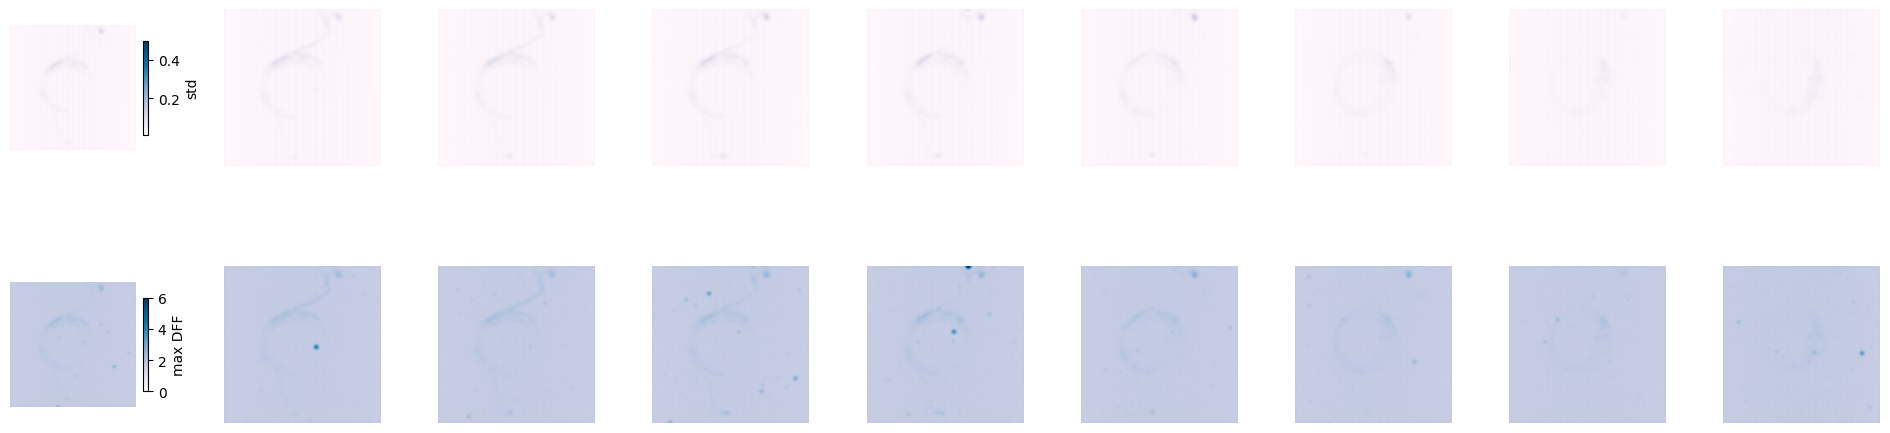

In [9]:
fig, ax = plt.subplots(2,dffStack["planes [µm]"].size,figsize=(19,6))
for i in range(dffStack["planes [µm]"].size):
    cb = ax[0,i].imshow(stdDff[i,:,:],cmap='PuBu',origin='upper', vmin=0.01, vmax=0.5)
    ax[0,i].axis('off')
    cb2 = ax[1,i].imshow(maxDff[i,:,:],cmap='PuBu',origin='upper', vmin=0, vmax=6)
    ax[1,i].axis('off')
plt.sca(ax[0,0])
plt.colorbar(cb, ax=ax[0,0], label='std',shrink=0.3)
plt.sca(ax[1,0])
plt.colorbar(cb2, ax=ax[1,0], label='max DFF',shrink=0.3)

fig.tight_layout()
fig.savefig(saveDir+sep+'DFF'+sep+'_'.join(['stdDFF_maxDFF_perPlane',genotype, region, flyID, condition, trial])+'.pdf')

## Specify ROIs for glomeruli in BU and knobs in EB

In [ ]:
if useNapari:
    viewer3D = napari.view_image(stdStack.values)
    if exists(sep.join([preprocDir,condition,'roiMask.npy'])):
        roiMask = np.load(sep.join([preprocDir,condition,'roiMask.npy'])) 
        #viewer3D.add_labels(roiMask, name='roiMask')

In [ ]:
if not exists(sep.join([preprocDir,condition])): 
    makedirs(sep.join([preprocDir,condition]))
np.save(sep.join([preprocDir,condition,'EBmask']), roiMask)
np.save(sep.join([preprocDir,condition,'BUmask']), roiMask)
print('Saved to:',sep.join([preprocDir,condition]))

Saved to: /Volumes/jayaramanlab/Hannah/Projects/FlyVR2P/Data//preproc/OLmapRFConflict/56H10_x_SP-S-7f/EB-BU/f03/cOLmapRF2-10
